## Transverse field Ising Model to demo primitives

In [4]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import SXGate, CXGate, SXdgGate, HGate
from qiskit.circuit.library import YGate, ZGate, XGate, UnitaryGate
import numpy as np

In [5]:
# define sqrt(Y) as a gate and its inverse (don't call the gate object as a function)
SYGate = YGate().power(0.5)
SYdgGate = SYGate.inverse()
SYdgGate.label = r"$\sqrt{Y}^\dag$"
SYGate.label = r"$\sqrt{Y}$"

def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits=0, trotter_barrier=False, layer_barriers=False):
    
    if num_cl_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits, num_cl_bits)

    for _trotter_step in range(num_trotter_steps):
        add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barrier:
            qc.barrier()
    return qc

def add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers=False):
    # Adding Rzz in the even layers
    for i in range(0, qc.num_qubits - 1, 2):
        qc.sdg([i, i + 1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
    # Adding Rzz in the odd layers
    for i in range(1, qc.num_qubits - 1, 2):
        qc.sdg([i, i + 1])
        qc.append(SYGate, [i+1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i+1])
    if layer_barriers:
        qc.barrier()
    qc.rx(rx_angle, range(qc.num_qubits))
    if layer_barriers:
        qc.barrier()

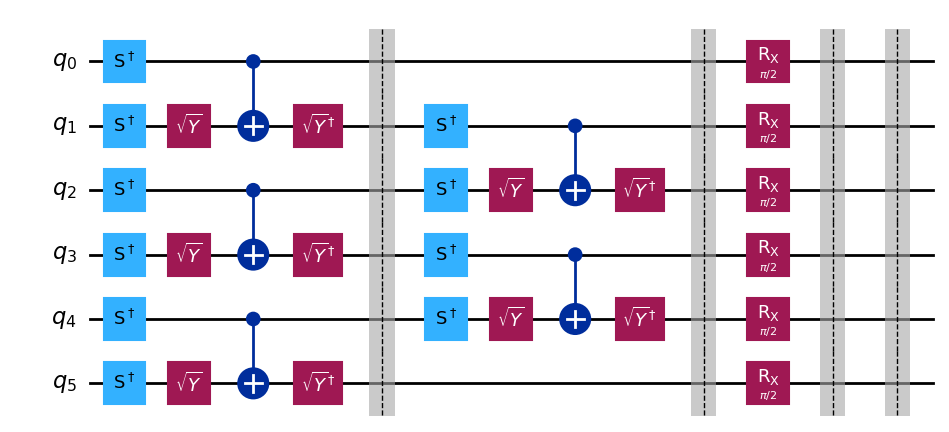

In [6]:
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barriers=True)
qc.draw(output='mpl', fold=-1)

##  Demo: Sampler

In [8]:
def append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=False, layer_barriers=False):
    
    for _trotter_step in range(num_trotter_steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barrier:
            qc.barrier()

def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers=False):
    qc.rx(- rx_angle, range(qc.num_qubits))
    if layer_barriers:
        qc.barrier()
    
    # Adding Rzz in the odd layers
    for i in range(1, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i+1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i+1])
        qc.s([i, i + 1])
    if layer_barriers:
        qc.barrier()
        
    # Adding Rzz in the even layers
    for i in range(0, qc.num_qubits - 1, 2):
        qc.append(SYGate, [i+1])
        qc.cx(i, i + 1)
        qc.append(SYdgGate, [i+1])
        qc.s([i, i + 1])      
    if layer_barriers:
        qc.barrier()


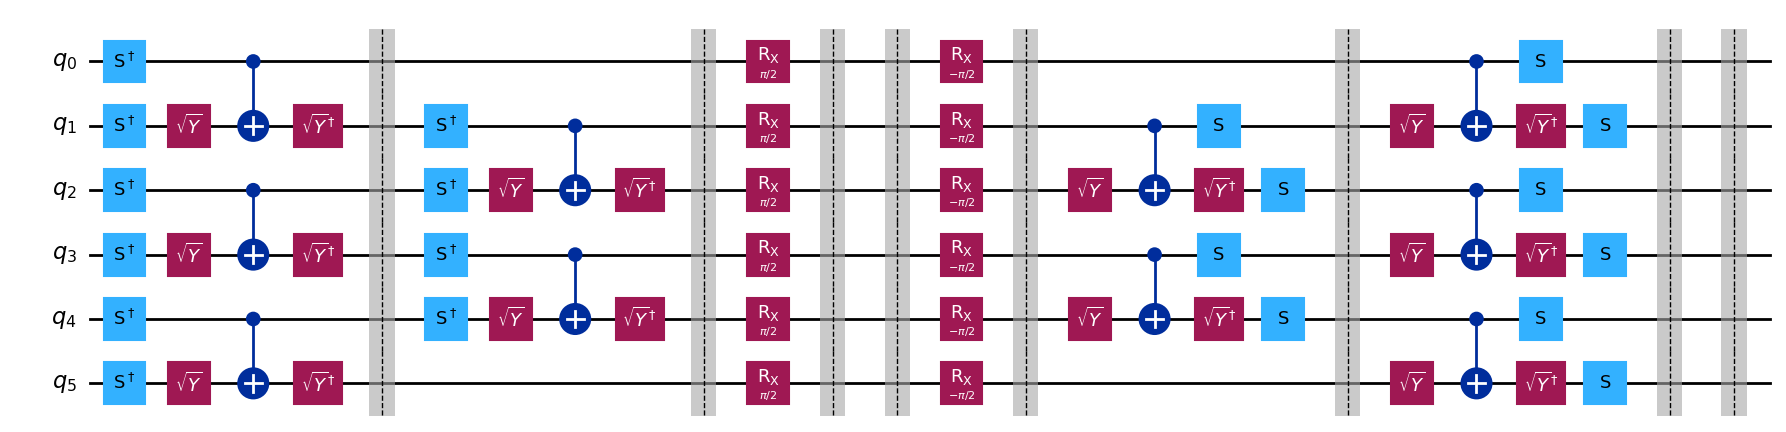

In [9]:
append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barriers=True)
qc.draw(output='mpl', fold=-1)

## Step 1: Map the problem to circuits and observables

In [10]:
max_trotter_steps = 10
num_qubits = 40
measured_qubits = [4, 5]

qc_list = []

for trotter_steps in range(1, max_trotter_steps + 1):

    qc = generate_1d_tfim_circuit(
        num_qubits,
        trotter_steps,        
        rx_angle,
        num_cl_bits=len(measured_qubits),
        trotter_barrier=True,
        layer_barriers=True
    )

    append_mirrored_1d_tfim_circuit(
        qc,
        num_qubits,
        trotter_steps,
        rx_angle,
        trotter_barrier=True,
        layer_barriers=True
    )

    qc.measure(measured_qubits, range(len(measured_qubits)))
    qc_list.append(qc)


In [ ]:
qc_list[1].draw(output='mpl', fold=-1)

## Step 2: Optimize

In [13]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(instance="open-instance")
service.backends()

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_torino')>]

In [14]:
from qiskit import transpile
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
 
backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
 
isa_circuit = pm.run(qc)
qc_transpiled_list = transpile(qc_list, backend=backend, optimization_level=3)


qiskit_runtime_service.__init__:WARNING:2026-01-27 12:11:47,629: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-27 12:11:48,188: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-01-27 12:11:51,071: Using instance: open-instance, plan: open


## Step 3: Execute in quantum hardware

In [17]:
from qiskit.primitives.base import BaseSamplerV2
from qiskit.primitives.containers.sampler_pub import SamplerPub, SamplerPubLike
from qiskit.providers import BackendV2
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [18]:
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"
 
# Create an Estimator object
estimator = Estimator(backend, options=options)
sampler = Sampler(backend)

In [20]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(backend)

job = sampler.run(qc_transpiled_list)  
job_id = job.job_id()
print("Job ID:", job_id)


Job ID: d5s5f47eglic739v262g


## Post-processing and plotting

In [21]:
job_id = 'd5s5f47eglic739v262g'
service = QiskitRuntimeService()
job = service.job(job_id)

qiskit_runtime_service.__init__:WARNING:2026-01-27 12:14:47,667: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [23]:
survival_probability_list = []
for trotter_step in range(max_trotter_steps):
    try:
        data=job.result()[trotter_step].data
        survival_probability_list.append(data.c.get_counts()['0' * len(measured_qubits)]/data.c.num_shots)
    except:
        survival_probability_list.append(0)
   

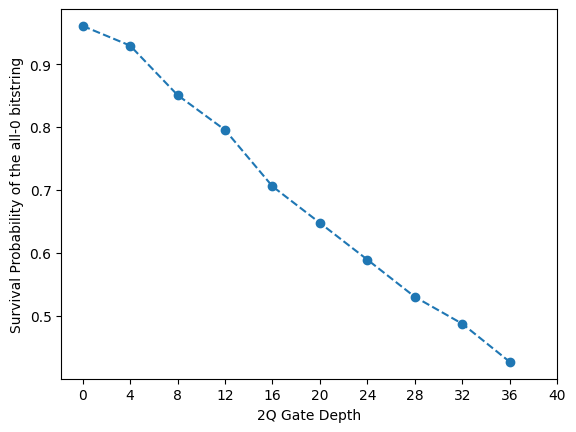

In [24]:
import matplotlib.pyplot as plt

plt.plot(list(range(0,4 * max_trotter_steps, 4)), survival_probability_list, '--o')
plt.xlabel('2Q Gate Depth')
plt.ylabel('Survival Probability of the all-0 bitstring')
plt.xticks(np.arange(0,44,4))
plt.show()

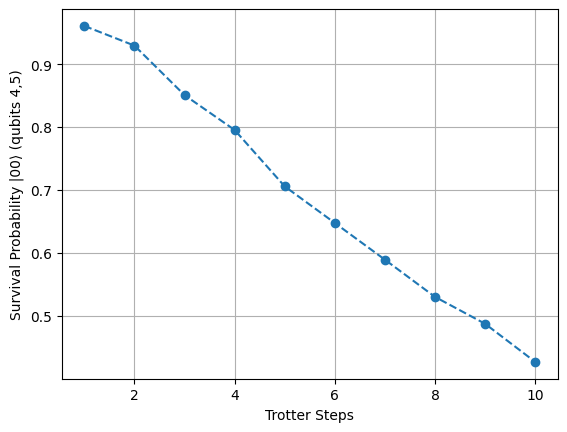

In [25]:
import matplotlib.pyplot as plt
import numpy as np

depth = np.arange(1, max_trotter_steps + 1)

plt.plot(depth, survival_probability_list, '--o')
plt.xlabel("Trotter Steps")
plt.ylabel("Survival Probability |00⟩ (qubits 4,5)")
plt.grid(True)
plt.show()
